# 简介
第 11 章介绍的 TRPO 算法在很多场景上的应用都很成功，**但是我们也发现它的计算过程非常复杂，每一步更新的运算量非常大**。于是，TRPO 算法的改进版——PPO 算法在 2017 年被提出，**PPO 基于 TRPO 的思想，但是其算法实现更加简单。**

并且大量的实验结果表明，与 TRPO 相比，PPO 能学习得一样好（甚至更快），这使得 PPO 成为非常流行的强化学习算法。如果我们想要尝试在一个新的环境中使用强化学习算法，那么 PPO 就属于可以首先尝试的算法。

In [3]:
from IPython.display import Image

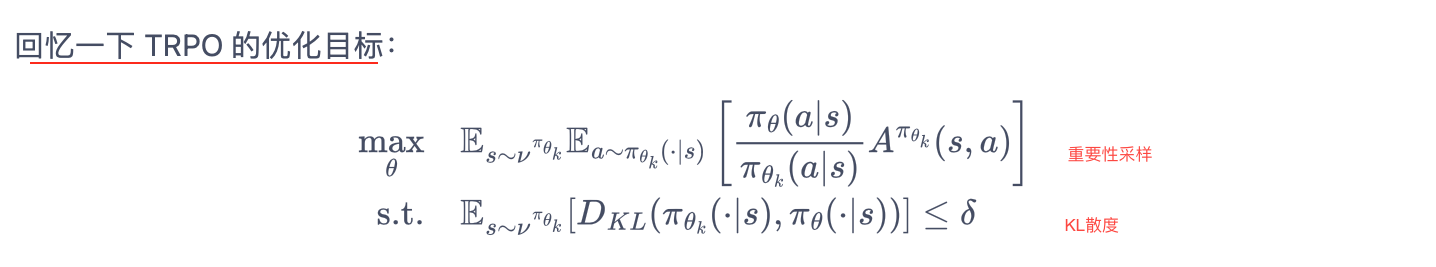

In [4]:
Image(filename='./image/ppo_01.png',width=600)

- TRPO 使用泰勒展开近似、共轭梯度、线性搜索等方法直接求解。
- PPO 的优化目标与 TRPO 相同，但 PPO 用了一些相对简单的方法来求解。
  - 具体来说，PPO 有两种形式：
    - 一是 PPO-惩罚，
    - 二是 PPO-截断
 
我们接下来对这两种形式进行介绍。

### PPO-惩罚

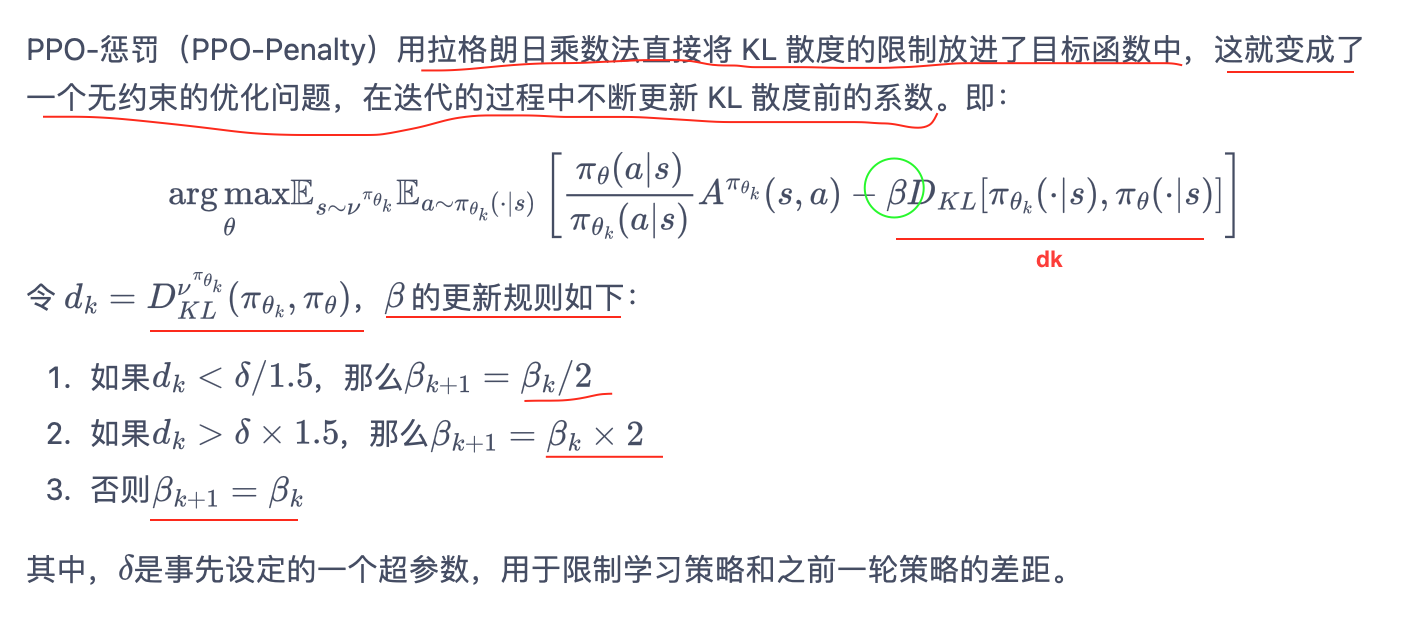

In [5]:
Image(filename='./image/ppo_02.png',width=600)

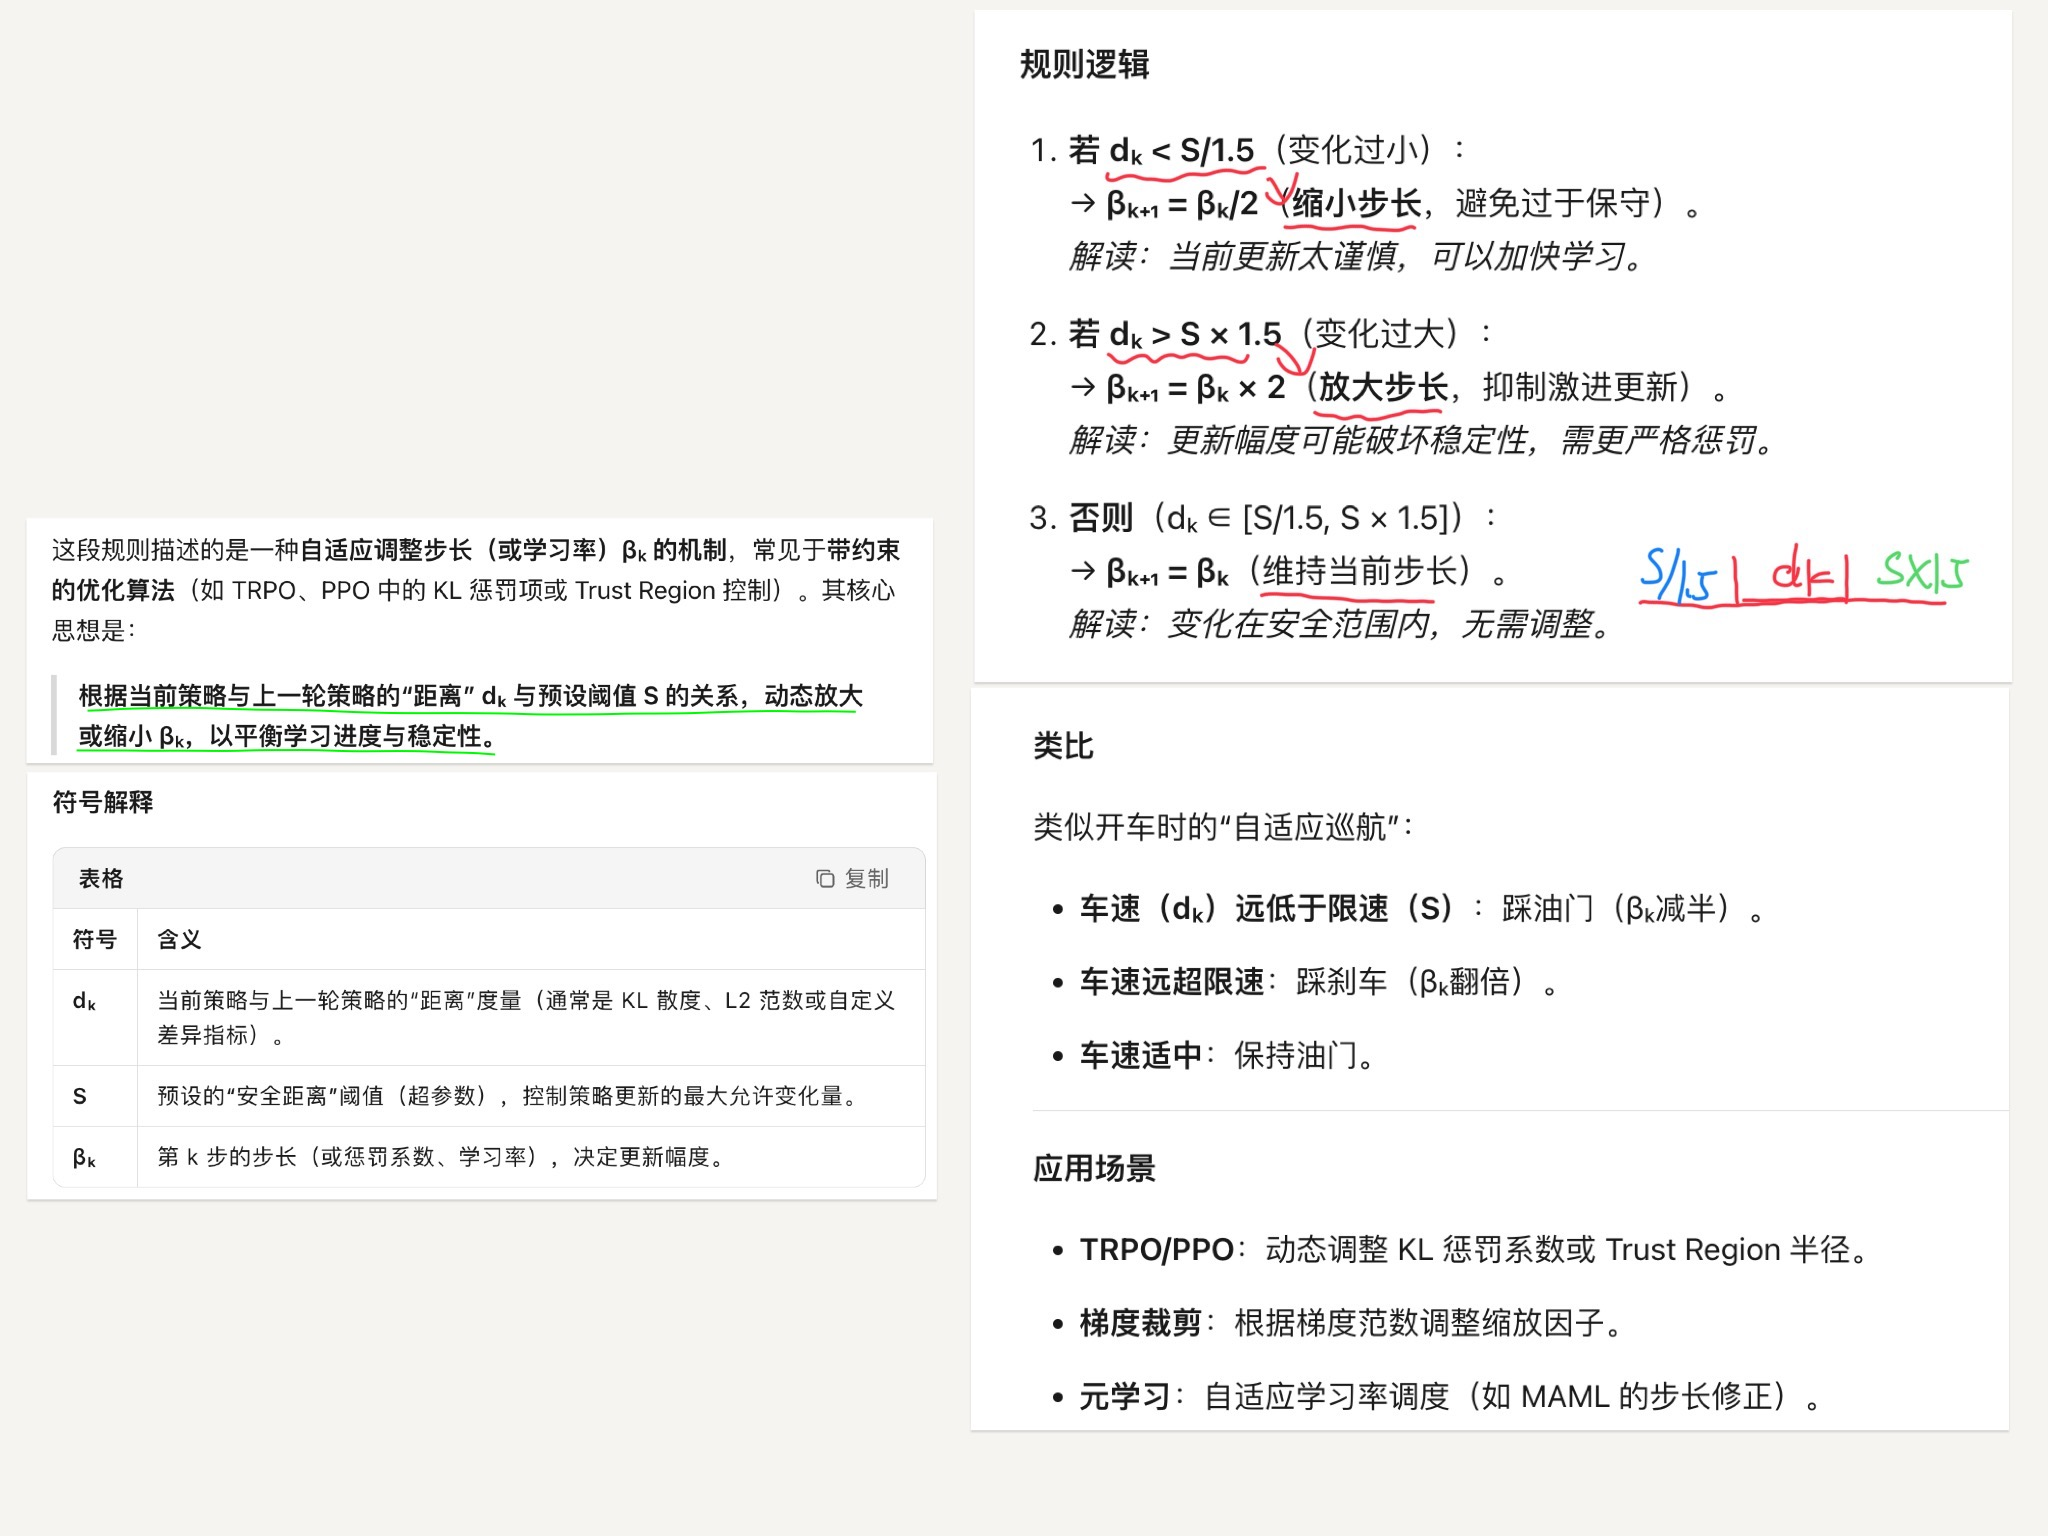

In [6]:
Image(filename='./image/ppo_03.jpg',width=600)

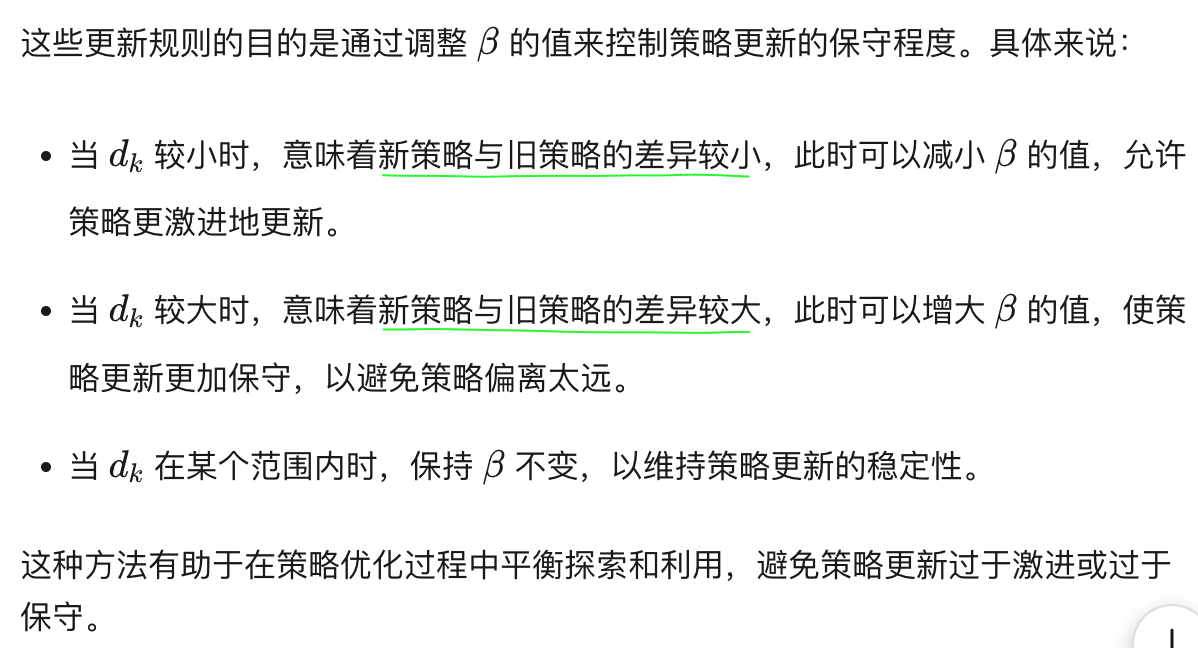

In [7]:
Image(filename='./image/ppo_04.png',width=600)

### PPO-截断

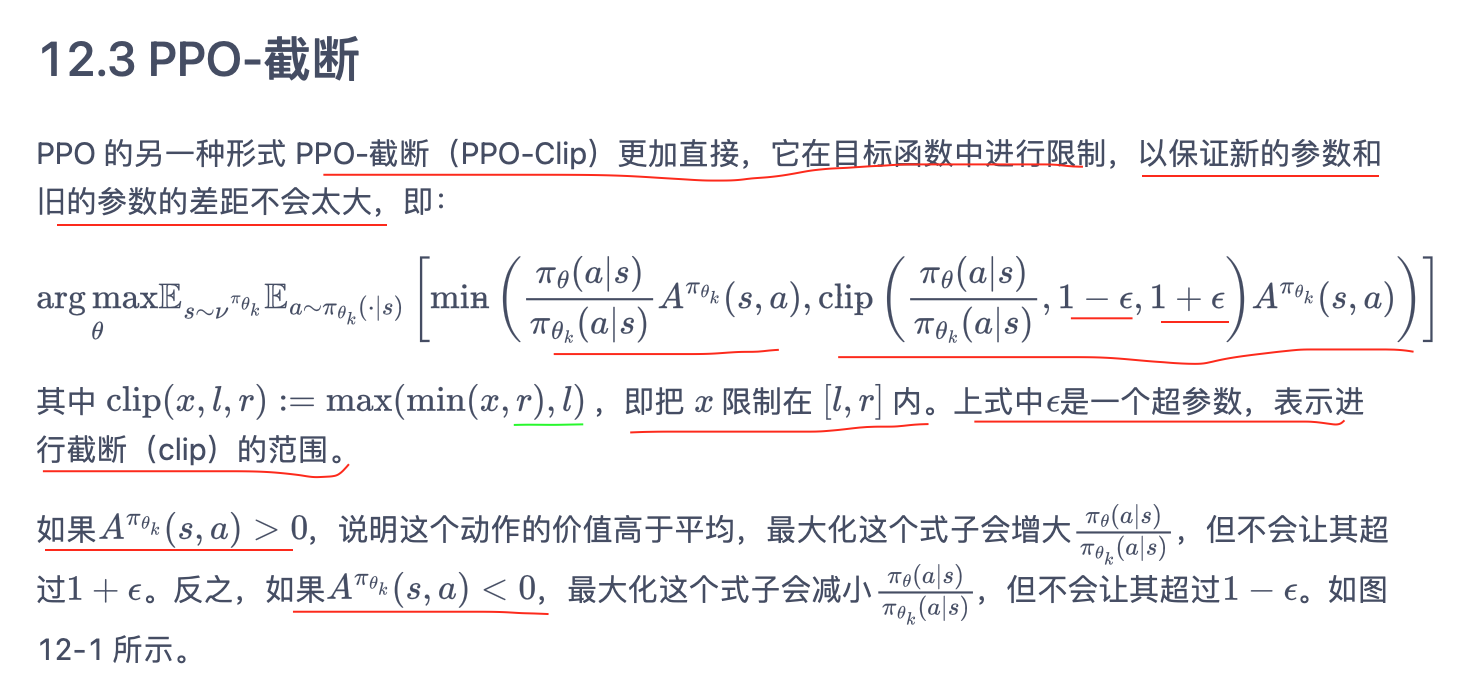

In [8]:
Image(filename='./image/ppo_clip.png',width=600)

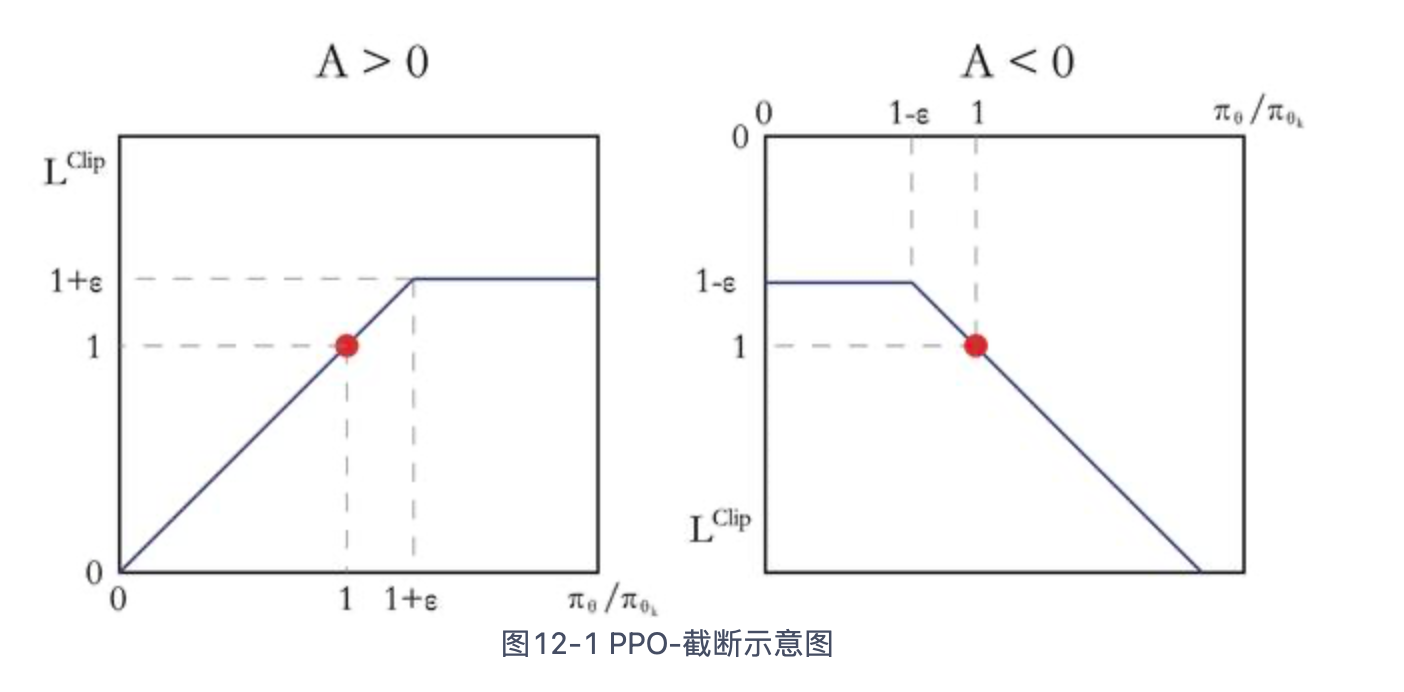

In [7]:
Image(filename='./image/ppo_clip_01.png',width=600)

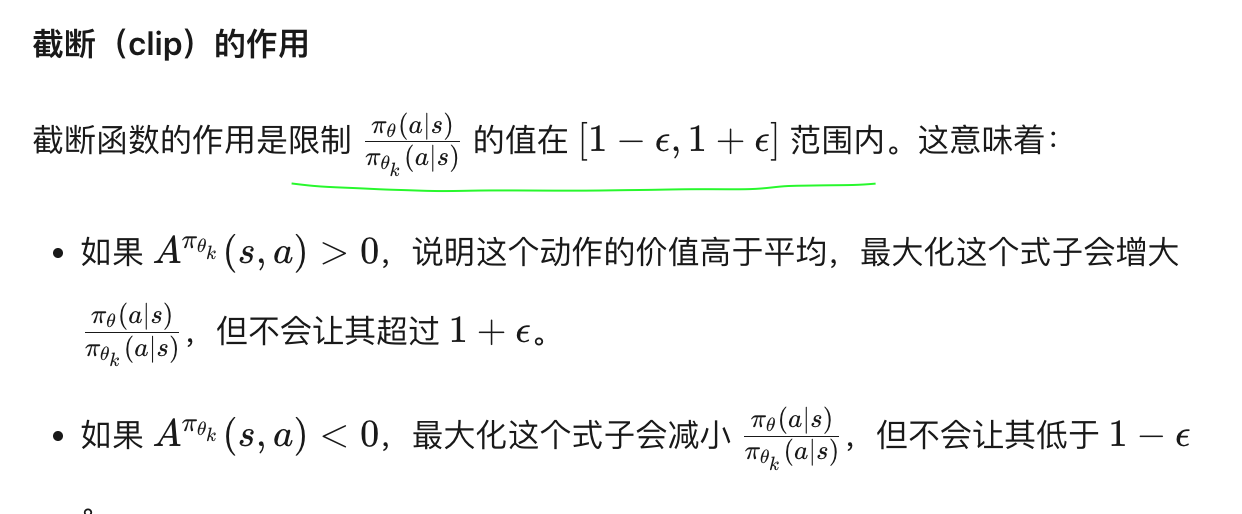

In [9]:
Image(filename='./image/ppo_clip_02.png',width=600)

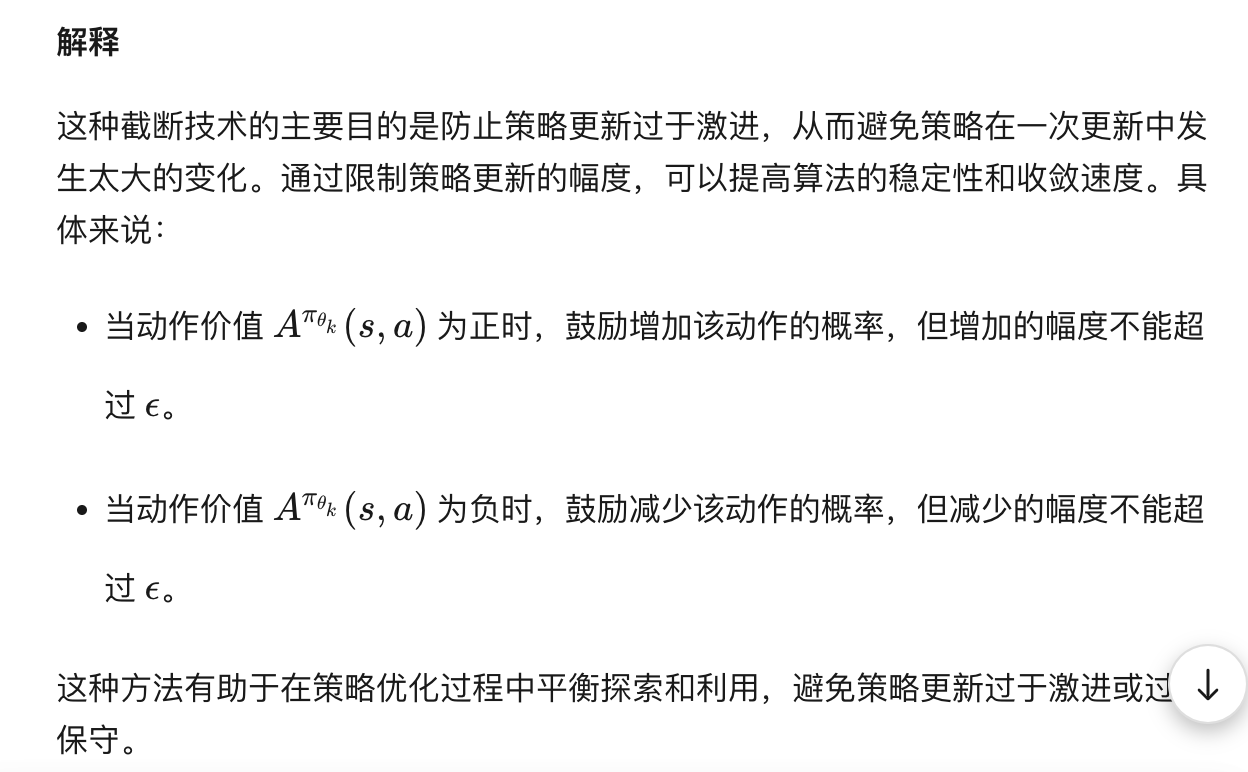

In [9]:
Image(filename='./image/ppo_clip_03.png',width=600)

# PPO 代码实践
大量实验表明，**PPO-截断总是比 PPO-惩罚表现得更好**。

因此下面我们专注于 PPO-截断的代码实现。

In [10]:
import gym
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as  plt
import rl_utils

class PolicyNet(torch.nn.Module):
    def __init__(self,state_dim,hidden_dim,action_dim):
        super(PolicyNet,self).__init__()
        self.fc1 = torch.nn.linear(state_dim,hidden_dim)
        self.fc2 = torch.nn.linear(hidden_dim,action_dim)
    def forward(self,x):
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x),dim=1)

class ValueNet(torch.nn.Module):
    def __init__(self,state_dim,hidden_dim):
        super(ValueNet,self).__init__()
        self.fc1 = torch.nn.Linear(state_dim,hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim,1)
    def forward(self,x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

'''PPO算法-采用截断方式'''

class PPO:
    def __init__(self,state_dim,hidden_dim,action_dim,actor_lr,critic_lr,lmbda,epochs,eps,gamma,device):
        self.actor = PolicyNet(state_dim,hidden_dim,action_dim).to(device)
        self.critic = ValueNet(state_dim,hidden_dim,action_dim).to(device)
        
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),lr = actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(),lr=critic_lr)
        
        self.gamma = gamma
        self.lmbda = lmbda
        self.epochs  = epochs
        self.eps = eps
        self.device = device
    def take_action(self,state):
        state = torch.tensor([state],dtype = torch.float).to(self.device)
        probs = self.actor(state)
        
        action_dist = torch.distributions(probs)
        action = action_dist.sample()
        return action.item()
    
    def update(self,transition_dict):
        states = torch.tensor(transition_dict['states'],dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'],dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'],dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],dtype=torch.float).view(-1, 1).to(self.device)
        # TD目标
        td_target = rewards + self.gamma * self.critic(next_states) * (1 - dones)
        # TD误差
        td_delta = td_target - self.critic(states)
        # 计算优势：GAE
        advantage = rl_utils.compute_advantage(self.gamma, self.lmbda,td_delta.cpu()).to(self.device)
        #  从计算图中分离出这些对数值，防止它们参与到梯度计算中，因为这些值在当前的策略更新中被视为常数
        # self.actor(states)：策略网络的输出，表示每个动作的概率分布。
        # .gather(1, actions)：从概率分布中提取每个样本对应动作的对数概率。
        old_log_probs = torch.log(self.actor(states).gather(1,actions)).detach()
        
        for _ in range(self.epochs):
            log_probs = torch.log(self.actor(states).gather(1, actions))
            
            # 其只是用到了上一轮策略的数据，而不是过去所有策略的数据。
            ratio = torch.exp(log_probs - old_log_probs)
            
            # 未截断
            surr1 = ratio * advantage
            # 截断的
            surr2 = torch.clamp(ratio,1-self.eps,1+self.eps) * advantage
            
            # PPO损失函数
            actor_loss = torch.mean(-torch.min(surr1,surr2))
            critic_loss = torch.mean(F.mse_loss(self.critic(states),td_target.detach()))
            
            self.actor_optimizer.zero_grad()
            self.critic_optimizer.zero_grad()
            # 计算梯度     
            actor_loss.backward()
            critic_loss.backward()
            
            # 更新参数
            self.actor_optimizer.step()
            self.critic_optimizer.step()
            

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/

In [11]:
'''在车杆环境中训练 PPO 算法'''
actor_lr = 1e-3
critic_lr = 1e-2
num_episodes = 500
hidden_dim = 128
gamma = 0.98
lmbda = 0.95
epochs = 10
eps = 0.2
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

env_name = 'CartPole-v0'
env = gym.make(env_name)
env.seed(0)
torch.manual_seed(0)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = PPO(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lmbda,epochs, eps, gamma, device)

return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes)

/opt/anaconda3/envs/gym3.10.10/lib/python3.10/site-packages/gym/envs/registration.py:555: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(


AttributeError: 'CartPoleEnv' object has no attribute 'seed'

In [ ]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO on {}'.format(env_name))
plt.show()

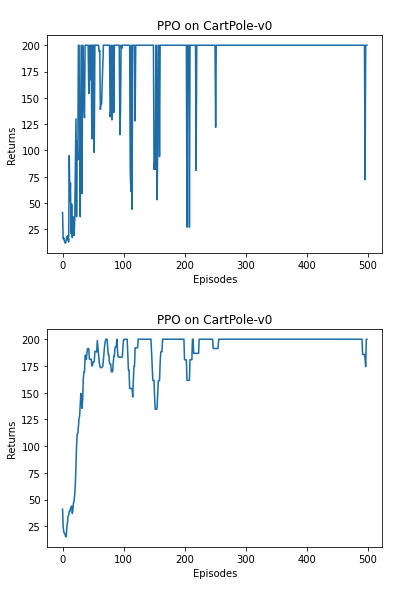

In [12]:
Image(filename='./image/ppo_cart1.png')

倒立摆是与连续动作交互的环境，同 TRPO 算法一样，**我们做一些修改，让策略网络输出连续动作高斯分布（Gaussian distribution）的均值和标准差。**

**后续的连续动作则在该高斯分布中采样得到。**

In [ ]:
class PolicyNetContinuous(torch.nn.Module):
    def __init__(self,state_dim,hidden_dim,action_dim):
        super(PolicyNetContinuous,self).__init__()
        self.fc1 = torch.nn.Linear(state_dim,hidden_dim)
        self.fc_mu = torch.nn.Linear(hidden_dim,action_dim) # 均值网络层
        self.fc_std = torch.nn.Linear(hidden_dim,action_dim)# 标准差网络层
    def forward(self,x):
        x = F.relu(self.fc1(x))
        # torch.tanh 的输出范围是 [-1, 1]，乘以2可以将输出范围扩展到 [-2, 2]。
        # 这种设计通常用于确保输出值在某个特定范围内，这在某些应用中可能是必要的。
        mu = 2.0 * torch.tanh(self.fc_mu(x))
        
        # F.softplus 是一个平滑的激活函数，其输出总是正的，
        # 这确保了标准差始终为正，避免了负的标准差或零标准差导致的数学问题
        std = F.softplus(self.fc_std(x))
        return mu,std

'''处理连续动作的PPO算法'''
class PPOContinuous:
    def __init__(self,state_dim,hidden_dim,action_dim,actor_lr,critic_lr,lmbda,epochs,eps,gamma,device):
        self.actor = PolicyNetContinuous(state_dim,hidden_dim,action_dim).to(device)
        self.critic = ValueNet(state_dim,hidden_dim).to(device)
        
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(),lr=critic_lr)
        
        self.gamma = gamma
        self.lmbda = lmbda
        self.epochs = epochs
        self.eps = eps
        self.device = device
    
    def take_action(self,state):
        state = torch.tensor([state],dtype=torch.float).to(self.device)
        # 计算 均值
        mu,std = self.actor(state)
        # 正态分布
        actor_dist = torch.distributions.Normal(mu,std)
        action = actor_dist.sample()
        return [action.item()]
    
    def update(self,transition_dict):
        states = torch.tensor(transition_dict['states'],dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions'],dtype=torch.float).view(-1,1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'],dtype=torch.float).view(-1,1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'],dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],dtype=torch.float).view(-1,1).to(self.device)
        
        rewards = (rewards + 8.0)/8.0 # 和TRPO一样,对奖励进行修改,方便训练
        td_target = rewards + self.gamma * self.critic(next_states)*(1-dones)
        # TD误差
        td_delta = td_target - self.critic(states)
        advantage = rl_utils.compute_advantage(self.gamma,self.lmbda,td_delta.cpu()).to(self.device)
        
        mu,std = self.actor(states)
        action_dists = torch.distributions.Normal(mu.detach(),srd.detach)
        # 动作是正太分布
        old_log_probs = action_dists.log_prob(actions)
        
        for _ in range(self.epochs):
            mu,std = self.actor(states)
            action_dists = torch.distributions.Normal(mu,std)
            log_probs = action_dists.log_prob(actions)
            
            # 新策略与旧策略的概率比值
            # 其只是用到了上一轮策略的数据，而不是过去所有策略的数据。
            ratio = torch.exp(log_probs - old_log_probs)
            
            # surr1 和 surr2：PPO 的两个目标函数，用于限制策略更新的幅度。
            surr1 = ratio * advantage
            # clamp：限制比值的范围，防止策略更新过大。
            surr2 = torch.clamp(ratio,1-self.eps,1+self.eps) * advantage
            
            actor_loss = torch.mean(-torch.min(surr1,surr2))
            critic_loss = torch.mean(F.mse_loss(self.critic(states),td_target.detach()))
            
            self.actor_optimizer.zero_grad()
            self.critic_optimizer.zero_grad()
            
            actor_loss.backward()
            critic_loss.backward()
            
            self.actor_optimizer.step()
            self.critic_optimizer.step()
            

In [ ]:
actor_lr = 1e-4
critic_lr = 5e-3
num_episodes = 2000
hidden_dim = 128
gamma = 0.9
lmbda = 0.9
epochs = 10
eps = 0.2
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

env_name = 'Pendulum-v0'
env = gym.make(env_name)
env.seed(0)
torch.manual_seed(0)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]  # 连续动作空间
agent = PPOContinuous(state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                      lmbda, epochs, eps, gamma, device)

return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes)

In [ ]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 21)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO on {}'.format(env_name))
plt.show()

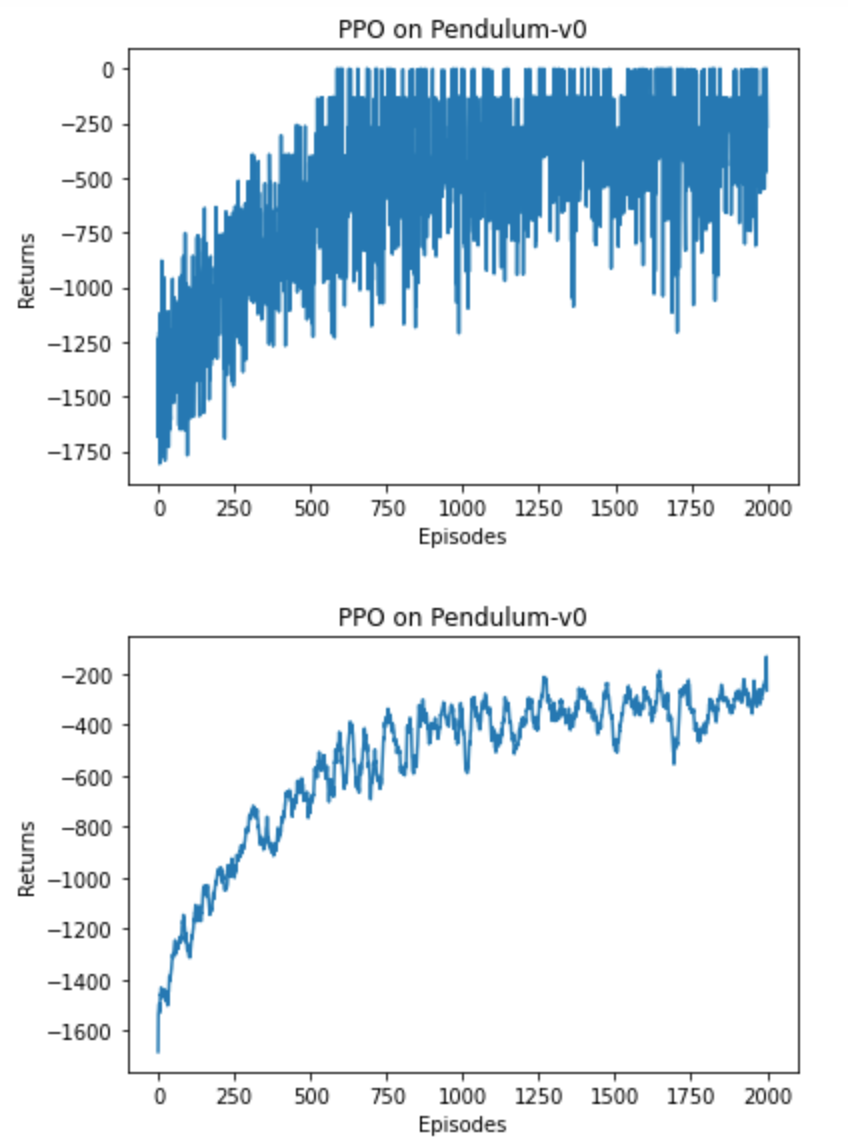

In [2]:
Image(filename='./image/ppo_chart2.png',width=300)

PPO 是 TRPO 的一种改进算法，**它在实现上简化了 TRPO 中的复杂计算**，并且它在实验中的性能大多数情况下会比 TRPO 更好，因此目前常被用作一种常用的基准算法。

**需要注意的是，TRPO 和 PPO 都属于在线策略学习算法**，即使优化目标中包含重要性采样的过程，**但其只是用到了上一轮策略的数据，而不是过去所有策略的数据。**

PPO 是 TRPO 的第一作者 John Schulman 从加州大学伯克利分校博士毕业后在 OpenAI 公司研究出来的。通过对 TRPO 计算方式的改进，PPO 成为了最受关注的深度强化学习算法之一，并且其论文的引用量也超越了 TRPO。

# 参考文献
[1] SCHULMAN J, FILIP W, DHARIWAL P, et al. Proximal policy optimization algorithms [J]. Machine Learning, 2017.